In [5]:
# Import required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv(
    r"C:\Users\mainu\Desktop\practice\prac\laptop_price.csv",
    encoding="latin1"
)

# Data Understanding

In [9]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [ ]:
df.shape

(1303, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [ ]:
df.isnull().sum()

,0
laptop_ID,0
Company,0
Product,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0


In [ ]:
df.duplicated().sum()

np.int64(0)

**Observations:**

- Dataset is small and clean

- No missing values

- No duplicates

- Suitable for KNN Regression

In [ ]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


- Mean > Median
- Price distribution is likely right-skewed.

# Feature Distribution

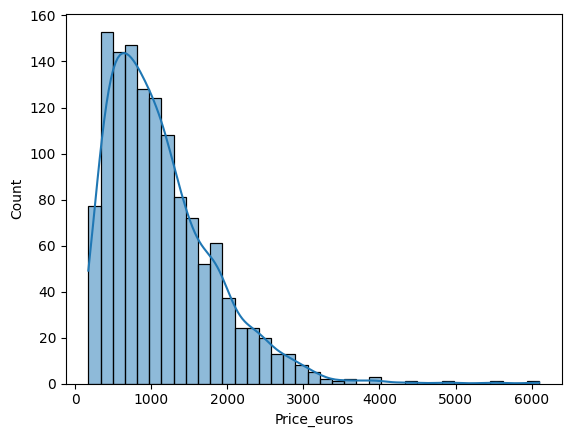

In [ ]:
# Target Variable Distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["Price_euros"], kde=True)
plt.show()

**Observation:**
- Price is not normally distributed

- Distribution is positively (right) skewed.

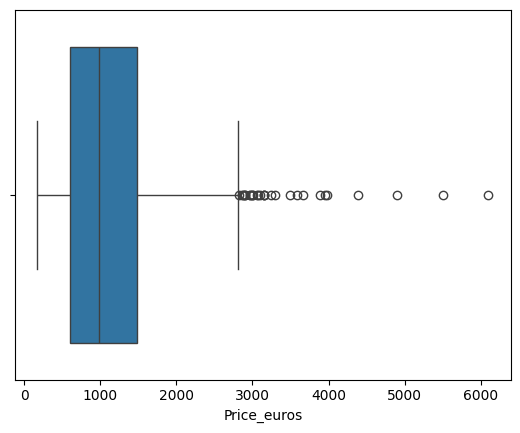

In [ ]:
# Boxplot
sns.boxplot(x=df["Price_euros"])
plt.show()

**Obserrvation:**
- Significant outliers are present.
- A few premium gaming/workstation laptops are creating extreme values.


# Correlation Analysis

In [ ]:
df.corr(numeric_only=True)

,laptop_ID,Inches,Price_euros
laptop_ID,1.000000,-0.087796,0.067830
Inches,-0.087796,1.000000,0.068197
Price_euros,0.067830,0.068197,1.000000


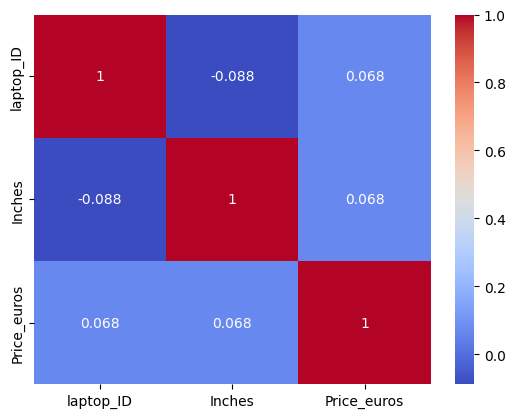

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

**Observation:**
- The correlation matrix shows that both laptop_ID (0.068) and Inches (0.068) have a very weak positive correlation with Price_euros.
- No strong linear relationships exist among the numerical features.
- Therefore, laptop_ID can be removed as an identifier, while Inches can be retained since KNN can capture non-linear patterns that correlation analysis may not reveal.

# Feature Engineering

In [24]:
df["Ram"].unique()

<ArrowStringArray>
['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB']
Length: 9, dtype: str

In [25]:
# Transformation
df["Ram"] = df["Ram"].str.replace("GB","").astype(int)

In [26]:
# Verify
print(df["Ram"].head())
print(df["Ram"].dtype)

0     8
1     8
2     8
3    16
4     8
Name: Ram, dtype: int64
int64


In [27]:
# Weight Feature Engineering
print(df["Weight"].unique()[:10])
df["Weight"] = df["Weight"].str.replace("kg", "").astype(float)
print(df["Weight"].head())
print(df["Weight"].dtype)

<ArrowStringArray>
['1.37kg', '1.34kg', '1.86kg', '1.83kg',  '2.1kg', '2.04kg',  '1.3kg',
  '1.6kg',  '2.2kg', '0.92kg']
Length: 10, dtype: str
0    1.37
1    1.34
2    1.86
3    1.83
4    1.37
Name: Weight, dtype: float64
float64


**Observation:**
- The Weight feature was converted from text format to numerical format by removing the "kg" suffix and converting the values to float.
- This makes the feature suitable for KNN distance calculations

In [28]:
df["Cpu"].unique()[:10]

<ArrowStringArray>
[      'Intel Core i5 2.3GHz',       'Intel Core i5 1.8GHz',
 'Intel Core i5 7200U 2.5GHz',       'Intel Core i7 2.7GHz',
       'Intel Core i5 3.1GHz',    'AMD A9-Series 9420 3GHz',
       'Intel Core i7 2.2GHz', 'Intel Core i7 8550U 1.8GHz',
 'Intel Core i5 8250U 1.6GHz',   'Intel Core i3 6006U 2GHz']
Length: 10, dtype: str

In [29]:
df["Cpu_Brand"] = df["Cpu"].apply(lambda x: x.split()[0])
df["Cpu_Brand"].value_counts()

Cpu_Brand
Intel      1240
AMD          62
Samsung       1
Name: count, dtype: int64

**Observation:**

- Intel processors dominate the dataset (95%+ of laptops), while AMD has a small presence and Samsung appears only once.
- CPU Brand may be an important categorical feature for predicting laptop prices.

In [30]:
df["Cpu_Speed"] = df["Cpu"].apply(lambda x: x.split()[-1])

df["Cpu_Speed"] = df["Cpu_Speed"].str.replace("GHz","").astype(float)

df[["Cpu_Brand","Cpu_Speed"]].head()


,Cpu_Brand,Cpu_Speed
0,Intel,2.3
1,Intel,1.8
2,Intel,2.5
3,Intel,2.7
4,Intel,3.1


**Observation:**
- The CPU feature was decomposed into CPU Brand and CPU Speed.
- CPU Brand captures manufacturer information (Intel, AMD, Samsung), while CPU Speed captures processing power in GHz.
- The original CPU column was removed after extracting useful information.

In [31]:
# Memory Feature Analysis
print(df["Memory"].unique()[:15])
print("\nTotal Unique Memory Configurations:", df["Memory"].nunique())

<ArrowStringArray>
[             '128GB SSD',    '128GB Flash Storage',              '256GB SSD',
              '512GB SSD',              '500GB HDD',    '256GB Flash Storage',
                '1TB HDD',     '32GB Flash Storage',   '128GB SSD +  1TB HDD',
 '256GB SSD +  256GB SSD',     '64GB Flash Storage',   '256GB SSD +  1TB HDD',
   '256GB SSD +  2TB HDD',               '32GB SSD',                '2TB HDD']
Length: 15, dtype: str

Total Unique Memory Configurations: 39


In [32]:
# Memory Feature Analysis

df["Memory_Type"] = df["Memory"].apply(
    lambda x: "SSD" if "SSD" in x
    else "HDD" if "HDD" in x
    else "Flash Storage" if "Flash Storage" in x
    else "Hybrid" if "Hybrid" in x
    else "Other"
)

print(df["Memory_Type"].value_counts())

Memory_Type
SSD              843
HDD              376
Flash Storage     74
Hybrid            10
Name: count, dtype: int64


**Observation:**

- SSD is the most common storage type (843 laptops), followed by HDD (376), Flash Storage (74), and Hybrid Storage (10).
- Since storage technology significantly impacts laptop performance and price, Memory_Type will be retained as a feature.

In [33]:
# Extract storage capacity correctly

df["Storage"] = df["Memory"].str.split().str[0]

df["Storage"] = df["Storage"].apply(
    lambda x: float(x.replace("TB", ""))*1000 if "TB" in x
    else float(x.replace("GB", ""))
)

df["Storage"] = df["Storage"].astype(int)

print(df[["Memory", "Storage"]].head())

                Memory  Storage
0            128GB SSD      128
1  128GB Flash Storage      128
2            256GB SSD      256
3            512GB SSD      512
4            256GB SSD      256


**Observation:**

- The Memory feature was decomposed into Storage Type and Storage Capacity.
- Storage capacity was converted into a numerical feature (GB), while storage technology (SSD, HDD, Flash Storage, Hybrid) was retained as a categorical feature.
- The original Memory column can now be removed

In [34]:
# Remove the Memory column
df = df.drop(columns=["Memory"])

In [35]:
print(df["ScreenResolution"].unique()[:15])

<ArrowStringArray>
[           'IPS Panel Retina Display 2560x1600',
                                      '1440x900',
                             'Full HD 1920x1080',
            'IPS Panel Retina Display 2880x1800',
                                      '1366x768',
                   'IPS Panel Full HD 1920x1080',
            'IPS Panel Retina Display 2304x1440',
     'IPS Panel Full HD / Touchscreen 1920x1080',
               'Full HD / Touchscreen 1920x1080',
              'Touchscreen / Quad HD+ 3200x1800',
               'IPS Panel Touchscreen 1920x1200',
                         'Touchscreen 2256x1504',
              'Quad HD+ / Touchscreen 3200x1800',
                            'IPS Panel 1366x768',
 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160']
Length: 15, dtype: str


In [36]:
# Touchscreen

df["Touchscreen"] = df["ScreenResolution"].apply(
    lambda x: 1 if "Touchscreen" in x else 0
)

# IPS Panel

df["IPS"] = df["ScreenResolution"].apply(
    lambda x: 1 if "IPS" in x else 0
)

# Resolution Width & Height

df["Resolution"] = df["ScreenResolution"].str.extract(r'(\d+x\d+)$')

df["X_res"] = df["Resolution"].str.split("x").str[0].astype(int)

df["Y_res"] = df["Resolution"].str.split("x").str[1].astype(int)

# Drop temporary columns

df.drop(columns=["ScreenResolution", "Resolution"], inplace=True)

# Verify

print(df[["Touchscreen", "IPS", "X_res", "Y_res"]].head())

   Touchscreen  IPS  X_res  Y_res
0            0    1   2560   1600
1            0    0   1440    900
2            0    0   1920   1080
3            0    1   2880   1800
4            0    1   2560   1600


**Observation:**

- The ScreenResolution feature was transformed into Touchscreen support, IPS panel availability, and screen resolution dimensions (X_res and Y_res).
- These engineered features better represent display quality and are expected to improve price prediction.

In [37]:
df["Gpu_Brand"] = df["Gpu"].apply(lambda x: x.split()[0])
print(df["Gpu_Brand"].value_counts())

Gpu_Brand
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64


- The GPU feature was simplified by extracting the GPU manufacturer (Intel, Nvidia, AMD, ARM).
- GPU brand is an important factor influencing laptop performance and price.
- The original GPU column can now be removed.

In [38]:
df["OpSys"].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [41]:
print(df.columns.tolist())

['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'Cpu', 'Ram', 'Gpu', 'Weight', 'Price_euros', 'Cpu_Speed', 'Cpu_Brand', 'Memory_Type', 'Storage', 'Touchscreen', 'IPS', 'X_res', 'Y_res', 'Gpu_Brand', 'OS']


In [42]:
if "OpSys" in df.columns:
    df["OS"] = df["OpSys"].apply(categorize_os)
    print(df["OS"].value_counts())
    df.drop(columns=["OpSys"], inplace=True)
else:
    print("OpSys column already processed or not present")

OpSys column already processed or not present


**Observation:**

- The operating system feature was grouped into broader categories to reduce complexity and improve model generalization.
- Windows is the dominant operating system in the dataset.

In [43]:
df.drop(columns=["laptop_ID"], inplace=True)

In [44]:
df.drop(columns=["Cpu","Gpu"], inplace=True)

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Company      1303 non-null   str    
 1   Product      1303 non-null   str    
 2   TypeName     1303 non-null   str    
 3   Inches       1303 non-null   float64
 4   Ram          1303 non-null   int64  
 5   Weight       1303 non-null   float64
 6   Price_euros  1303 non-null   float64
 7   Cpu_Speed    1303 non-null   float64
 8   Cpu_Brand    1303 non-null   str    
 9   Memory_Type  1303 non-null   str    
 10  Storage      1303 non-null   int64  
 11  Touchscreen  1303 non-null   int64  
 12  IPS          1303 non-null   int64  
 13  X_res        1303 non-null   int64  
 14  Y_res        1303 non-null   int64  
 15  Gpu_Brand    1303 non-null   str    
 16  OS           1303 non-null   str    
dtypes: float64(4), int64(6), str(7)
memory usage: 235.4 KB


In [11]:
y = df["Price_euros"]

X = df.drop(columns=["Price_euros"])

print(X.shape)
print(y.shape)

(1303, 12)
(1303,)


In [12]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(num_cols)
print(cat_cols)

['laptop_ID', 'Inches']
['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']


C:\Users\mainu\AppData\Local\Temp\ipykernel_29596\2981972156.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


- Numerical Features   = 9
- Categorical Features = 7
- Total Features       = 16

In [13]:
# encode the categorical columns.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

transformer = ColumnTransformer([
    ("cat", OrdinalEncoder(), cat_cols)
], remainder="passthrough")

In [14]:
# Transform
X_encoded = transformer.fit_transform(X)

In [15]:
# Convert back to DataFrame
import pandas as pd
X_encoded = pd.DataFrame(X_encoded)
X_encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.0,300.0,4.0,23.0,65.0,8.0,4.0,58.0,8.0,38.0,1.0,13.3
1,1.0,301.0,4.0,1.0,63.0,8.0,2.0,51.0,8.0,35.0,2.0,13.3
2,7.0,50.0,3.0,8.0,74.0,8.0,16.0,53.0,4.0,74.0,3.0,15.6
3,1.0,300.0,4.0,25.0,85.0,1.0,29.0,9.0,8.0,71.0,4.0,15.4
4,1.0,300.0,4.0,23.0,67.0,8.0,16.0,59.0,8.0,38.0,5.0,13.3


# Feature Selection

In [16]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression

selector = SelectKBest(
    score_func=f_regression,
    k=10
)

X_selected = selector.fit_transform(X_encoded, y)

In [17]:
selected_features = X.columns[selector.get_support()]
print(selected_features)

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Weight'],
      dtype='str')


**Observation:**

- Feature selection using SelectKBest and f_regression identified the top 10 features most strongly associated with laptop price.
- These features were retained for model development, while less informative features were removed.

# Train-Test Split:

In [18]:
X = df[selected_features]
y = df["Price_euros"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1042, 10)
(261, 10)
(1042,)
(261,)


- The dataset was successfully split into 80% training data and 20% testing data.
- The training set contains 1042 records, while the testing set contains 261 records.

# Data Preprocessing

In [48]:
# Separate Numerical and Categorical Features
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

C:\Users\mainu\AppData\Local\Temp\ipykernel_29596\1573674852.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

transformer = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ), cat_cols)
])

In [60]:
from sklearn.neighbors import KNeighborsRegressor

pipeline = make_pipeline(
    transformer,
    KNeighborsRegressor(n_neighbors=5)
)

In [47]:
print(X_train.columns.tolist())

['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Weight']


In [61]:
# Transform Data
from sklearn.neighbors import KNeighborsRegressor

pipeline = make_pipeline(
    transformer,
    KNeighborsRegressor(n_neighbors=5)
)

pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


**Observation:**

- All 10 selected features were successfully transformed.
- Numerical features were scaled using StandardScaler, and categorical features were encoded using OrdinalEncoder.
- The transformed datasets are ready for KNN Regression.

# Model Building- KNN Regressor

In [62]:
y_pred = pipeline.predict(X_test)

print(y_pred[:5])

[ 639.198  639.198  471.18  1069.    1542.2  ]


In [63]:
import joblib

joblib.dump(pipeline, "laptop_price_pipeline.pkl")

print("Pipeline saved successfully!")

Pipeline saved successfully!


**Observation:**

- The KNN Regressor successfully generated continuous price predictions for the test dataset.
- The model is now ready for performance evaluation.

# Model Evaluation

In [64]:
import os

print(os.listdir())

['app.py', 'basics.py', 'etc', 'Include', 'KhajaMainuddin_Laptop_Price_Prediction.ipynb', 'laptop_price.csv', 'laptop_price_pipeline.pkl', 'Lib', 'model.pkl', 'pyvenv.cfg', 'registration_form.py', 'requirements.txt', 'Scripts', 'share', 'transformer.pkl', 'widgets.py']


In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = X_test.shape[0]
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adj_r2)

MAE: 261.0950498084291
MSE: 172087.0802339617
RMSE: 414.8337983264643
R2 Score: 0.6611969018298143
Adjusted R2: 0.6476447779030068


**Observation:**

- The KNN Regressor achieved an R² score of 0.6612, indicating that approximately 66.12% of the variation in laptop prices is explained by the selected features.
- The RMSE of 414.83 euros suggests that predictions deviate from actual prices by about 415 euros on average.
- Overall, the model demonstrates moderate predictive performance.

# Actual vs Predicted Price Plot

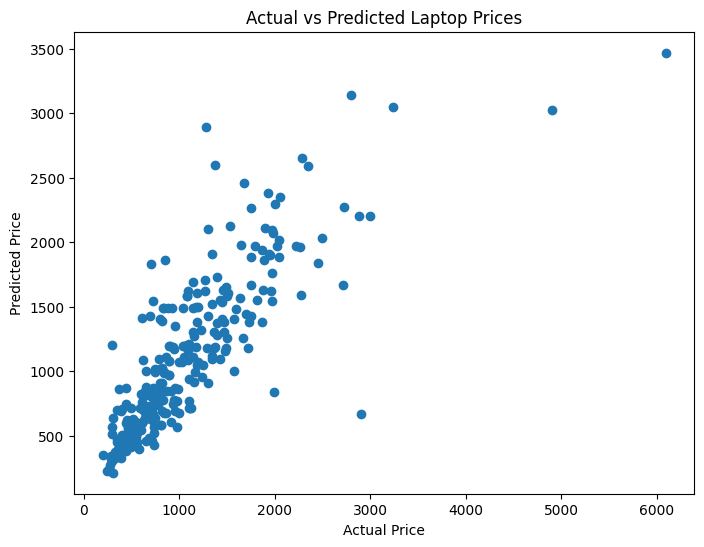

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Laptop Prices")

plt.show()

- The scatter plot shows a clear positive relationship between actual and predicted laptop prices, indicating that the KNN Regressor successfully captures the overall pricing pattern.
- Most observations are clustered around the expected trend, although prediction errors increase for high-priced laptops, suggesting the model performs better on low- to mid-range laptops than on premium models.

# Hyperparameter Tuning

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

for k in [3,5,7,9,11,13,15]:

    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_trans, y_train)

    y_pred = knn.predict(X_test_trans)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    r2 = r2_score(y_test, y_pred)

    print(f"K={k} | RMSE={rmse:.2f} | R2={r2:.4f}")

K=3 | RMSE=414.03 | R2=0.6625
K=5 | RMSE=414.83 | R2=0.6612
K=7 | RMSE=427.99 | R2=0.6394
K=9 | RMSE=430.57 | R2=0.6350
K=11 | RMSE=421.94 | R2=0.6495
K=13 | RMSE=422.16 | R2=0.6491
K=15 | RMSE=427.61 | R2=0.6400


- Hyperparameter tuning was performed by testing multiple K values.
- The best performance was achieved at K=3, which produced the lowest RMSE (414.03) and highest R² score (0.6625).
- Increasing K beyond 5 resulted in decreased model performance, indicating that smaller neighborhood sizes are more suitable for this dataset.

# K vs RMSE Plot

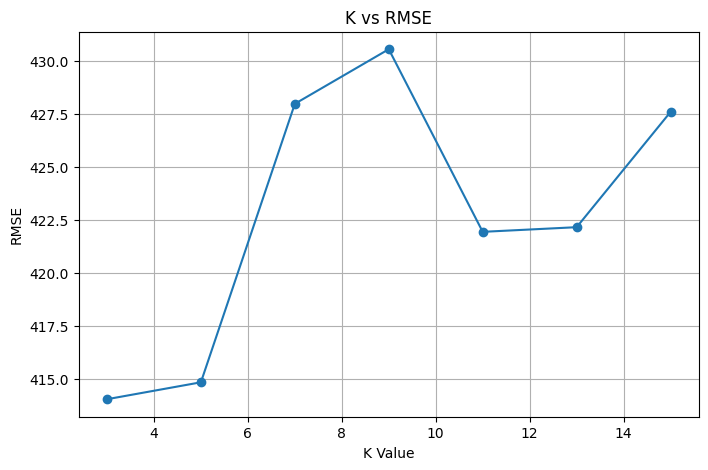

In [ ]:
import matplotlib.pyplot as plt

k_values = [3,5,7,9,11,13,15]
rmse_values = [414.03,414.83,427.99,430.57,421.94,422.16,427.61]

plt.figure(figsize=(8,5))
plt.plot(k_values, rmse_values, marker='o')
plt.xlabel("K Value")
plt.ylabel("RMSE")
plt.title("K vs RMSE")
plt.grid(True)
plt.show()

- The RMSE curve shows that the lowest prediction error occurs at K = 3 (RMSE = 414.03).
- As K increases beyond 5, the error generally increases, indicating a decline in model performance.
- Therefore, K = 3 is the optimal value based on RMSE.

# K vs R² Plot

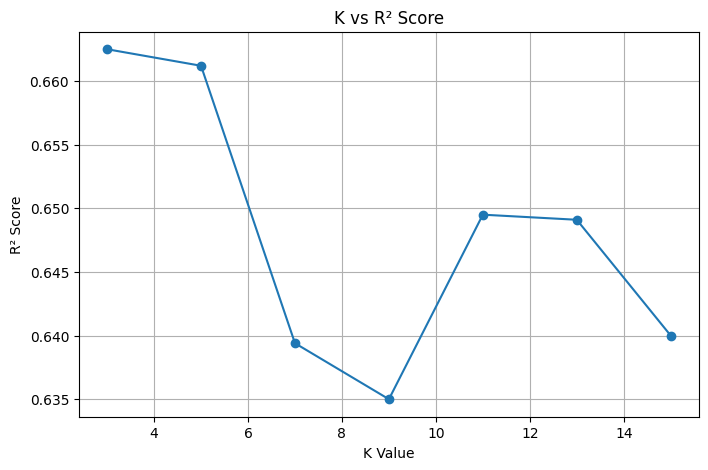

In [ ]:
k_values = [3,5,7,9,11,13,15]
r2_values = [0.6625,0.6612,0.6394,0.6350,0.6495,0.6491,0.6400]

plt.figure(figsize=(8,5))
plt.plot(k_values, r2_values, marker='o')
plt.xlabel("K Value")
plt.ylabel("R² Score")
plt.title("K vs R² Score")
plt.grid(True)
plt.show()

- The R² curve shows that the highest coefficient of determination is achieved at K = 3 (R² = 0.6625).
- The R² score decreases for larger K values, suggesting that the model explains less variance in laptop prices as the neighborhood size increases.

# Hyperparameter Tuning Conclusion
- Hyperparameter tuning revealed that K = 3 provides the best balance between bias and variance.
- It achieved the lowest RMSE (414.03) and highest R² Score (0.6625) among all tested K values.
- Hence, K = 3 was selected as the optimal hyperparameter for the final KNN Regressor model.

# Final Conclusion

- Built a Laptop Price Prediction model using KNN Regressor.
- Performed EDA to understand the dataset and identify patterns.
- Cleaned and transformed features such as RAM, CPU, Storage, GPU, OS, and Screen Resolution.
- Applied Feature Selection to choose the most important features.
- Split the data into 80% training and 20% testing sets.
- Used encoding and scaling for data preprocessing.
- Trained the KNN Regressor model and evaluated its performance.
- Achieved an R² Score of 0.66 and RMSE of 414 euros.
- Performed Hyperparameter Tuning with different K values.
- Found K = 3 as the best parameter for the model.
- Successfully predicted laptop prices with good accuracy using machine learning techniques.

In [55]:
import joblib

joblib.dump(transformer, "transformer.pkl")

print("Transformer saved successfully!")

Transformer saved successfully!


In [56]:
import os

print(os.listdir())

['app.py', 'basics.py', 'etc', 'Include', 'KhajaMainuddin_Laptop_Price_Prediction.ipynb', 'laptop_price.csv', 'Lib', 'model.pkl', 'pyvenv.cfg', 'registration_form.py', 'requirements.txt', 'Scripts', 'share', 'transformer.pkl', 'widgets.py']


In [57]:
print(num_cols)
print(cat_cols)

['laptop_ID', 'Inches']
['Company', 'Product', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Weight']


In [58]:
df.head(10)

,Company,Product,TypeName,Inches,Ram,Weight,Price_euros,Cpu_Speed,Cpu_Brand,Memory_Type,Storage,Touchscreen,IPS,X_res,Y_res,Gpu_Brand,OS
0,Apple,MacBook Pro,Ultrabook,13.3,8,1.37,1339.69,2.3,Intel,SSD,128,0,1,2560,1600,Intel,Mac
1,Apple,Macbook Air,Ultrabook,13.3,8,1.34,898.94,1.8,Intel,Flash Storage,128,0,0,1440,900,Intel,Mac
2,HP,250 G6,Notebook,15.6,8,1.86,575.00,2.5,Intel,SSD,256,0,0,1920,1080,Intel,No OS
3,Apple,MacBook Pro,Ultrabook,15.4,16,1.83,2537.45,2.7,Intel,SSD,512,0,1,2880,1800,AMD,Mac
4,Apple,MacBook Pro,Ultrabook,13.3,8,1.37,1803.60,3.1,Intel,SSD,256,0,1,2560,1600,Intel,Mac
5,Acer,Aspire 3,Notebook,15.6,4,2.10,400.00,3.0,AMD,HDD,500,0,0,1366,768,AMD,Windows
6,Apple,MacBook Pro,Ultrabook,15.4,16,2.04,2139.97,2.2,Intel,Flash Storage,256,0,1,2880,1800,Intel,Mac
7,Apple,Macbook Air,Ultrabook,13.3,8,1.34,1158.70,1.8,Intel,Flash Storage,256,0,0,1440,900,Intel,Mac
8,Asus,ZenBook UX430UN,Ultrabook,14.0,16,1.30,1495.00,1.8,Intel,SSD,512,0,0,1920,1080,Nvidia,Windows
9,Acer,Swift 3,Ultrabook,14.0,8,1.60,770.00,1.6,Intel,SSD,256,0,1,1920,1080,Intel,Windows
